# JetVLAD Tutorial: Training and Plotting the Results
This tutorial trains the JetVLAD heavy-flavor tagger from preselected a preselected .root file and then test validates the training against preselected validation and test .root files. The resulting ROC and background rejection curves are plotted.
### WARNING:This notebook must sit in the repository folder next to train.py, utils.py and model/, all the model and dataset code lives in those files.

Paper: [Identifying Heavy-Flavor Jets Using Vectors of Locally Aggregated Descriptors](https://arxiv.org/abs/2005.01842)

## 1. Setup
The first step is to setup the necessary packages to read the data in the .root files. This is performed by "pip install" below.

In [1]:
# Install anything missing (pip skips packages already present).
%pip install -q torch numpy scikit-learn matplotlib uproot


Note: you may need to restart the kernel to use updated packages.


In [2]:
# On Colab: clone the repository if we are not already inside it.
import os
REPO_URL = 'https://github.com/cplatte24/NetVLAD-tagger-pytorch.git'

if not os.path.isfile('train.py'):
    if REPO_URL:
        !git clone {REPO_URL} repo
        %cd repo
    else:
        raise FileNotFoundError('train.py not found - run this notebook from the '
                                'repository folder, or set REPO_URL above.')
print('working directory:', os.getcwd())


working directory: /Users/plattecw/JetVLAD_JupyterNotebook/NetVLAD-tagger-pytorch


## 2. Configuration — same arguments as train.sh
In the configuration, the path to the training, validation, and test paths are set. Additionally, the input variables to the model used for the jet classificiation are set (VARIABLES). The table below shows what input variables are the model can be trained on (tracking, fragmentation, and secondary vertex).<br> 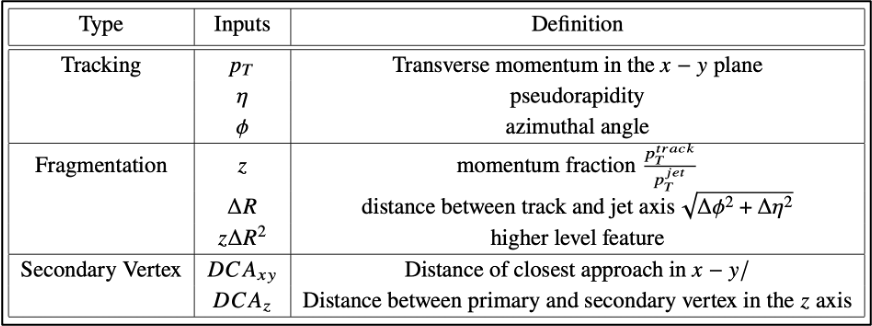 <br>

In [3]:
# The path to the .root files, the default is set to preuploaded files.
TRAIN_PATH = 'training_data/output_5to10_9_fixed.root'
VAL_PATH   = 'validation_data/output_5to10_validation_all.root'
TEST_PATH  = 'testing_data/output_5to10_test_all.root'

# Model parameters
VARIABLES = 'trkvtx' #The variables: trk, vtx, trkvtx, trkfrag, trkvtxfrag
CLUSTERS  = 33
DEPTH     = 2
SIGNAL    = 'hf_vs_l' #The signal: c_vs_b, hf_vs_l, c_vs_all, b_vs_all
JOBID     = 'jetvlad_notebook_run'   # outputs located in training_runs/<JOBID>/

for p in (TRAIN_PATH, VAL_PATH, TEST_PATH):
    assert os.path.isfile(p), f'missing input file: {p}'
    print(f'{p}: {os.path.getsize(p)/1e6:.0f} MB')


training_data/output_5to10_9_fixed.root: 29 MB
validation_data/output_5to10_validation_all.root: 43 MB
testing_data/output_5to10_test_all.root: 43 MB


## 3. Train

This is train.sh as a notebook cell: it runs train.py in a separate process with the
arguments above. Training uses early stopping on validation loss; when it finishes it
evaluates on the test sample and writes the curves to
training_runs/<JOBID>/*_roc.txt and *_pr.txt. Progress prints below as it runs.
Loading the TTrees into memory can take a while before the first epoch starts.

In [7]:
!python train.py \
        --train-data {TRAIN_PATH} \
        --test-data {TEST_PATH} \
        --val-data {VAL_PATH} \
        --variables {VARIABLES} \
        --clusters {CLUSTERS} \
        --depth {DEPTH} \
        --signal {SIGNAL} \
        --jobid {JOBID}


Loading test dataset... Done
Loading val dataset... Done
Loading train dataset... Done
NetVLADTagger(
  (vlad): NetVLAD(
    (batch_norm): BatchNorm1d(33, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (units): Sequential(
    (0): ResidualUnit(
      (linear1): Linear(in_features=165, out_features=165, bias=True)
      (linear2): Linear(in_features=165, out_features=165, bias=True)
      (bn1): BatchNorm1d(165, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(165, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): CELU(alpha=1.0, inplace=True)
    )
    (1): Dropout(p=0.5, inplace=False)
    (2): ResidualUnit(
      (linear1): Linear(in_features=165, out_features=165, bias=True)
      (linear2): Linear(in_features=165, out_features=165, bias=True)
      (bn1): BatchNorm1d(165, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(165, eps=1e-05, momentum=0

Epoch: [2][ 300/1327]	Time  0.010 ( 0.041)	Data  0.000 ( 0.033)	Loss 2.8873e-02 (5.7772e-02)	Acc  99.22 ( 98.42)
Epoch: [2][ 400/1327]	Time  0.009 ( 0.033)	Data  0.000 ( 0.025)	Loss 8.0021e-02 (5.6532e-02)	Acc  97.27 ( 98.46)
Epoch: [2][ 500/1327]	Time  0.008 ( 0.028)	Data  0.000 ( 0.020)	Loss 7.3598e-02 (5.5367e-02)	Acc  98.05 ( 98.50)
Epoch: [2][ 600/1327]	Time  0.010 ( 0.025)	Data  0.000 ( 0.016)	Loss 5.7118e-02 (5.5359e-02)	Acc  98.05 ( 98.50)
Epoch: [2][ 700/1327]	Time  0.009 ( 0.023)	Data  0.000 ( 0.014)	Loss 1.5497e-02 (5.4299e-02)	Acc  99.61 ( 98.53)
Epoch: [2][ 800/1327]	Time  0.010 ( 0.021)	Data  0.000 ( 0.012)	Loss 5.5219e-02 (5.4169e-02)	Acc  99.22 ( 98.51)
Epoch: [2][ 900/1327]	Time  0.009 ( 0.020)	Data  0.000 ( 0.011)	Loss 4.4346e-02 (5.3633e-02)	Acc  98.83 ( 98.53)
Epoch: [2][1000/1327]	Time  0.008 ( 0.019)	Data  0.000 ( 0.010)	Loss 2.5412e-02 (5.2884e-02)	Acc  99.61 ( 98.55)
Epoch: [2][1100/1327]	Time  0.009 ( 0.018)	Data  0.000 ( 0.009)	Loss 3.0836e-02 (5.2051e-02)	Acc

Val: [ 300/1882]	Time  0.004 ( 0.041)	Loss 2.0995e-02 (4.0781e-02)	Acc  99.61 ( 98.90)
Val: [ 400/1882]	Time  0.003 ( 0.031)	Loss 7.2539e-02 (4.1246e-02)	Acc  97.66 ( 98.89)
Val: [ 500/1882]	Time  0.003 ( 0.026)	Loss 8.3724e-02 (4.1258e-02)	Acc  97.66 ( 98.89)
Val: [ 600/1882]	Time  0.003 ( 0.022)	Loss 3.2479e-02 (4.1057e-02)	Acc  99.22 ( 98.90)
Val: [ 700/1882]	Time  0.003 ( 0.019)	Loss 3.0403e-02 (4.1146e-02)	Acc  99.22 ( 98.90)
Val: [ 800/1882]	Time  0.004 ( 0.017)	Loss 2.7349e-02 (4.1078e-02)	Acc  99.22 ( 98.90)
Val: [ 900/1882]	Time  0.003 ( 0.016)	Loss 1.7711e-02 (4.1068e-02)	Acc  99.22 ( 98.91)
Val: [1000/1882]	Time  0.003 ( 0.015)	Loss 4.5638e-02 (4.1112e-02)	Acc  98.83 ( 98.91)
Val: [1100/1882]	Time  0.004 ( 0.014)	Loss 4.8736e-02 (4.1264e-02)	Acc  98.44 ( 98.90)
Val: [1200/1882]	Time  0.003 ( 0.013)	Loss 4.7480e-02 (4.1321e-02)	Acc  98.05 ( 98.90)
Val: [1300/1882]	Time  0.003 ( 0.012)	Loss 3.3271e-02 (4.1252e-02)	Acc  99.22 ( 98.90)
Val: [1400/1882]	Time  0.003 ( 0.011)	Loss 

Epoch: [7][   0/1327]	Time 22.612 (22.612)	Data 22.588 (22.588)	Loss 4.2796e-02 (4.2796e-02)	Acc  99.22 ( 99.22)
Epoch: [7][ 100/1327]	Time  0.011 ( 0.234)	Data  0.000 ( 0.224)	Loss 6.6241e-02 (4.8779e-02)	Acc  98.83 ( 98.70)
Epoch: [7][ 200/1327]	Time  0.007 ( 0.122)	Data  0.000 ( 0.113)	Loss 3.1704e-02 (4.6681e-02)	Acc  98.44 ( 98.76)
Epoch: [7][ 300/1327]	Time  0.008 ( 0.084)	Data  0.000 ( 0.075)	Loss 7.0429e-02 (4.7734e-02)	Acc  98.44 ( 98.74)
Epoch: [7][ 400/1327]	Time  0.010 ( 0.065)	Data  0.000 ( 0.057)	Loss 1.1573e-01 (4.8358e-02)	Acc  97.66 ( 98.73)
Epoch: [7][ 500/1327]	Time  0.007 ( 0.054)	Data  0.000 ( 0.045)	Loss 2.4850e-02 (4.7735e-02)	Acc  98.83 ( 98.73)
Epoch: [7][ 600/1327]	Time  0.007 ( 0.046)	Data  0.000 ( 0.038)	Loss 4.9689e-02 (4.7051e-02)	Acc  98.05 ( 98.73)
Epoch: [7][ 700/1327]	Time  0.012 ( 0.041)	Data  0.000 ( 0.033)	Loss 3.0030e-02 (4.6520e-02)	Acc  99.61 ( 98.74)
Epoch: [7][ 800/1327]	Time  0.012 ( 0.037)	Data  0.000 ( 0.028)	Loss 1.9293e-02 (4.5649e-02)	Acc

Val: [   0/1882]	Time 11.487 (11.487)	Loss 4.4870e-02 (4.4870e-02)	Acc  98.44 ( 98.44)
Val: [ 100/1882]	Time  0.003 ( 0.117)	Loss 4.6335e-02 (3.5356e-02)	Acc  98.83 ( 99.04)
Val: [ 200/1882]	Time  0.003 ( 0.060)	Loss 3.4877e-02 (3.6598e-02)	Acc  99.22 ( 98.96)
Val: [ 300/1882]	Time  0.004 ( 0.041)	Loss 1.7156e-02 (3.5660e-02)	Acc 100.00 ( 99.00)
Val: [ 400/1882]	Time  0.003 ( 0.032)	Loss 6.8009e-02 (3.6226e-02)	Acc  98.05 ( 98.99)
Val: [ 500/1882]	Time  0.004 ( 0.026)	Loss 7.9906e-02 (3.6330e-02)	Acc  97.66 ( 98.99)
Val: [ 600/1882]	Time  0.004 ( 0.022)	Loss 3.3724e-02 (3.6251e-02)	Acc  99.22 ( 99.00)
Val: [ 700/1882]	Time  0.004 ( 0.020)	Loss 2.5023e-02 (3.6376e-02)	Acc  99.61 ( 99.00)
Val: [ 800/1882]	Time  0.003 ( 0.018)	Loss 2.7915e-02 (3.6306e-02)	Acc  99.22 ( 99.01)
Val: [ 900/1882]	Time  0.003 ( 0.016)	Loss 1.6421e-02 (3.6293e-02)	Acc  99.22 ( 99.01)
Val: [1000/1882]	Time  0.004 ( 0.015)	Loss 4.2800e-02 (3.6332e-02)	Acc  99.22 ( 99.02)
Val: [1100/1882]	Time  0.003 ( 0.014)	Loss 

...

Epoch: [24][ 500/1327]	Time  0.009 ( 0.029)	Data  0.000 ( 0.020)	Loss 1.6040e-02 (3.7139e-02)	Acc  99.22 ( 98.94)
Epoch: [24][ 600/1327]	Time  0.008 ( 0.026)	Data  0.000 ( 0.017)	Loss 2.9345e-02 (3.6615e-02)	Acc  98.83 ( 98.95)
Epoch: [24][ 700/1327]	Time  0.008 ( 0.024)	Data  0.000 ( 0.015)	Loss 1.4046e-02 (3.5839e-02)	Acc  99.61 ( 98.97)
Epoch: [24][ 800/1327]	Time  0.009 ( 0.022)	Data  0.000 ( 0.013)	Loss 5.9207e-02 (3.5903e-02)	Acc  97.66 ( 98.97)
Epoch: [24][ 900/1327]	Time  0.010 ( 0.020)	Data  0.000 ( 0.011)	Loss 5.6705e-02 (3.5755e-02)	Acc  98.83 ( 98.97)
Epoch: [24][1000/1327]	Time  0.009 ( 0.019)	Data  0.000 ( 0.010)	Loss 2.6118e-02 (3.5556e-02)	Acc  99.22 ( 98.98)
Epoch: [24][1100/1327]	Time  0.009 ( 0.018)	Data  0.000 ( 0.009)	Loss 3.0004e-02 (3.5468e-02)	Acc  99.61 ( 98.99)
Epoch: [24][1200/1327]	Time  0.009 ( 0.017)	Data  0.000 ( 0.009)	Loss 3.8742e-02 (3.5175e-02)	Acc  98.83 ( 98.99)
Epoch: [24][1300/1327]	Time  0.009 ( 0.017)	Data  0.000 ( 0.008)	Loss 2.8104e-02 (3.5058

Val: [ 600/1882]	Time  0.004 ( 0.022)	Loss 4.4085e-02 (3.5927e-02)	Acc  99.22 ( 99.12)
Val: [ 700/1882]	Time  0.004 ( 0.019)	Loss 3.2463e-02 (3.6218e-02)	Acc  99.61 ( 99.12)
Val: [ 800/1882]	Time  0.003 ( 0.017)	Loss 3.5300e-02 (3.6138e-02)	Acc  99.22 ( 99.12)
Val: [ 900/1882]	Time  0.002 ( 0.016)	Loss 1.8052e-02 (3.6167e-02)	Acc  99.22 ( 99.12)
Val: [1000/1882]	Time  0.004 ( 0.014)	Loss 4.6170e-02 (3.6281e-02)	Acc  98.83 ( 99.13)
Val: [1100/1882]	Time  0.004 ( 0.014)	Loss 6.1831e-02 (3.6396e-02)	Acc  98.44 ( 99.12)
Val: [1200/1882]	Time  0.003 ( 0.013)	Loss 4.1627e-02 (3.6497e-02)	Acc  98.44 ( 99.12)
Val: [1300/1882]	Time  0.003 ( 0.012)	Loss 3.3030e-02 (3.6412e-02)	Acc  99.61 ( 99.12)
Val: [1400/1882]	Time  0.003 ( 0.011)	Loss 5.2140e-02 (3.6306e-02)	Acc  99.22 ( 99.13)
Val: [1500/1882]	Time  0.003 ( 0.011)	Loss 4.5420e-02 (3.6379e-02)	Acc  97.66 ( 99.13)
Val: [1600/1882]	Time  0.003 ( 0.010)	Loss 1.2383e-02 (3.6091e-02)	Acc 100.00 ( 99.14)
Val: [1700/1882]	Time  0.004 ( 0.010)	Loss 

Epoch: [29][ 200/1327]	Time  0.011 ( 0.057)	Data  0.000 ( 0.048)	Loss 2.6730e-02 (3.5542e-02)	Acc  99.22 ( 99.02)
Epoch: [29][ 300/1327]	Time  0.009 ( 0.041)	Data  0.000 ( 0.032)	Loss 4.6372e-02 (3.5683e-02)	Acc  98.83 ( 99.01)
Epoch: [29][ 400/1327]	Time  0.007 ( 0.033)	Data  0.000 ( 0.024)	Loss 5.0611e-02 (3.5662e-02)	Acc  99.61 ( 99.00)
Epoch: [29][ 500/1327]	Time  0.008 ( 0.028)	Data  0.000 ( 0.019)	Loss 1.7394e-02 (3.5401e-02)	Acc  99.61 ( 99.02)
Epoch: [29][ 600/1327]	Time  0.008 ( 0.025)	Data  0.000 ( 0.016)	Loss 2.9265e-02 (3.5254e-02)	Acc  98.44 ( 99.02)
Epoch: [29][ 700/1327]	Time  0.009 ( 0.023)	Data  0.000 ( 0.014)	Loss 2.0959e-02 (3.4972e-02)	Acc  99.22 ( 99.02)
Epoch: [29][ 800/1327]	Time  0.009 ( 0.021)	Data  0.000 ( 0.012)	Loss 3.5086e-02 (3.4719e-02)	Acc  98.44 ( 99.02)
Epoch: [29][ 900/1327]	Time  0.010 ( 0.020)	Data  0.000 ( 0.011)	Loss 2.3886e-02 (3.4462e-02)	Acc  99.22 ( 99.03)
Epoch: [29][1000/1327]	Time  0.009 ( 0.019)	Data  0.000 ( 0.010)	Loss 6.9510e-02 (3.4505

Val: [ 200/1882]	Time  0.004 ( 0.059)	Loss 3.5641e-02 (3.1415e-02)	Acc  99.61 ( 99.13)
Val: [ 300/1882]	Time  0.004 ( 0.040)	Loss 1.6006e-02 (3.0789e-02)	Acc 100.00 ( 99.16)
Val: [ 400/1882]	Time  0.004 ( 0.031)	Loss 6.1979e-02 (3.1488e-02)	Acc  98.83 ( 99.14)
Val: [ 500/1882]	Time  0.003 ( 0.025)	Loss 8.1163e-02 (3.1563e-02)	Acc  98.05 ( 99.15)
Val: [ 600/1882]	Time  0.004 ( 0.022)	Loss 3.7258e-02 (3.1737e-02)	Acc  99.22 ( 99.16)
Val: [ 700/1882]	Time  0.004 ( 0.019)	Loss 2.2887e-02 (3.1952e-02)	Acc  99.61 ( 99.15)
Val: [ 800/1882]	Time  0.003 ( 0.017)	Loss 3.0405e-02 (3.1878e-02)	Acc  99.22 ( 99.16)
Val: [ 900/1882]	Time  0.003 ( 0.016)	Loss 1.4335e-02 (3.1845e-02)	Acc 100.00 ( 99.16)
Val: [1000/1882]	Time  0.004 ( 0.014)	Loss 4.4601e-02 (3.1939e-02)	Acc  98.83 ( 99.16)
Val: [1100/1882]	Time  0.003 ( 0.013)	Loss 6.5706e-02 (3.2134e-02)	Acc  98.44 ( 99.16)
Val: [1200/1882]	Time  0.003 ( 0.013)	Loss 3.7258e-02 (3.2216e-02)	Acc  98.44 ( 99.15)
Val: [1300/1882]	Time  0.003 ( 0.012)	Loss 

 * Val loss 0.031
Best AUC-ROC: 0.978799317570048
Best acc: 99.1332516560417
Best val loss: 0.030005414332112228
Final ROC-AUC: 0.977739124528124


## 4. Plot the results

Reads the *_roc.txt and *_pr.txt files that train.py just wrote and plots them, using
the averaging code from training_runs/jetvlad_test_run/make_plots.py. If several runs
share the same JOBID folder the curves are averaged with a spread band; with one run
the band collapses to the line.

In [9]:
# Curve averaging, from make_plots.py (paths parameterized instead of hardcoded).
import glob
import numpy as np
from sklearn.metrics import auc

run_dir = os.path.join('training_runs', JOBID)
mean_fpr = np.linspace(0.0001, 1, 8000)
mean_rec = np.linspace(1, 0.0001, 8000)

def generate_roc_curve(folder):
    tprs, aucs = [], []
    for file in glob.glob(os.path.join(folder, '*_roc.txt')):
        fpr, tpr = np.loadtxt(file)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0001
        aucs.append(auc(fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std(tprs, axis=0)
    print(f'{len(tprs)} ROC file(s), mean AUC {auc(mean_fpr, mean_tpr):.4f} +- {np.std(aucs):.4f}')
    return mean_tpr, np.minimum(mean_tpr + std_tpr, 1), np.maximum(mean_tpr - std_tpr, 0)

def generate_pr_curve(folder):
    precs = []
    for file in glob.glob(os.path.join(folder, '*_pr.txt')):
        prec, rec = np.loadtxt(file)
        precs.append(np.interp(mean_rec[::-1], rec[::-1], prec[::-1]))
        precs[-1][0] = 1
    mean_prec = np.mean(precs, axis=0)[::-1]
    mean_prec[-1] = 1
    std_prec = np.std(precs, axis=0)
    return mean_prec, np.minimum(mean_prec + std_prec, 1), np.maximum(mean_prec - std_prec, 0)

tpr_trkvtx, tprs_upper, tprs_lower = generate_roc_curve(run_dir)
prec_trkvtx, precs_upper, precs_lower = generate_pr_curve(run_dir)

# Legend text - edit to match your sample.
label_title = ('JetVLAD, Pythia8, cross-section weighted\n'
               r'$\sqrt{s} = 200$ GeV, thermal bkg, anti-$k_{T}$ jets R = 0.4' + '\n'
               r'$5 < p_{T,jet} < 10$ GeV/$c$, $|\eta_{jet}| < 0.6$')


1 ROC file(s), mean AUC 0.9777 +- 0.0000


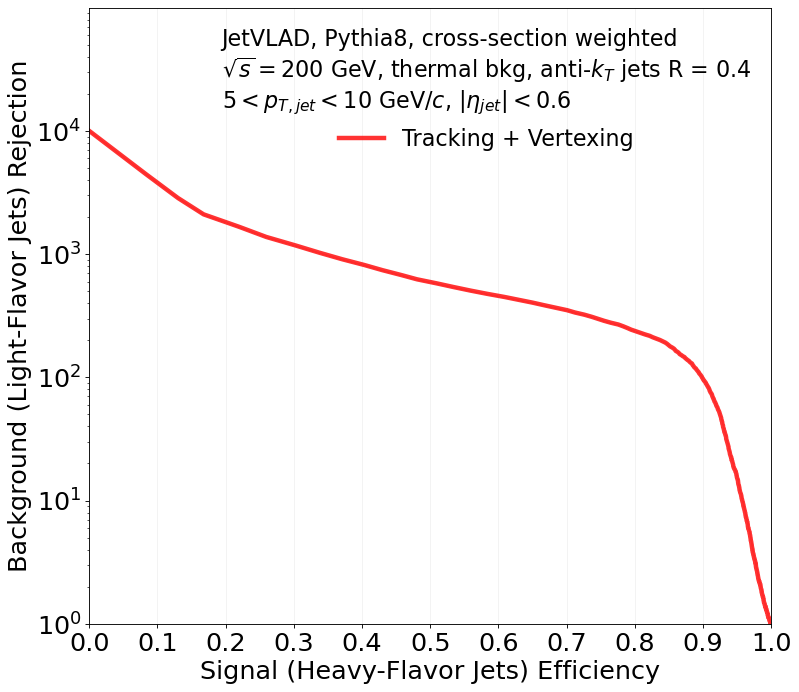

In [10]:
# Background rejection vs signal efficiency (make_plots.py layout).
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 10), dpi=80, facecolor='w', edgecolor='k')
plt.plot(tpr_trkvtx, 1/mean_fpr, color='red', label=r'Tracking + Vertexing',
         lw=4, alpha=.8, linestyle='-')
plt.fill_betweenx(1/mean_fpr, tprs_lower, tprs_upper, color='red', alpha=.2)
plt.xlim([0, 1])
plt.xticks(np.arange(0, 1.1, 0.1), fontsize=23)
plt.yscale('log')
plt.ylim([1e0, 1e5])
plt.yticks([1e0, 1e1, 1e2, 1e3, 1e4], fontsize=23)
plt.grid(axis='x', color='0.95')
plt.xlabel('Signal (Heavy-Flavor Jets) Efficiency', fontsize=23)
plt.ylabel('Background (Light-Flavor Jets) Rejection', fontsize=23)
plt.legend(loc='upper right', fancybox=True, framealpha=0., fontsize=20,
           title=label_title, title_fontsize=20)
plt.savefig('netvlad_rejection.pdf', bbox_inches='tight')
plt.show()


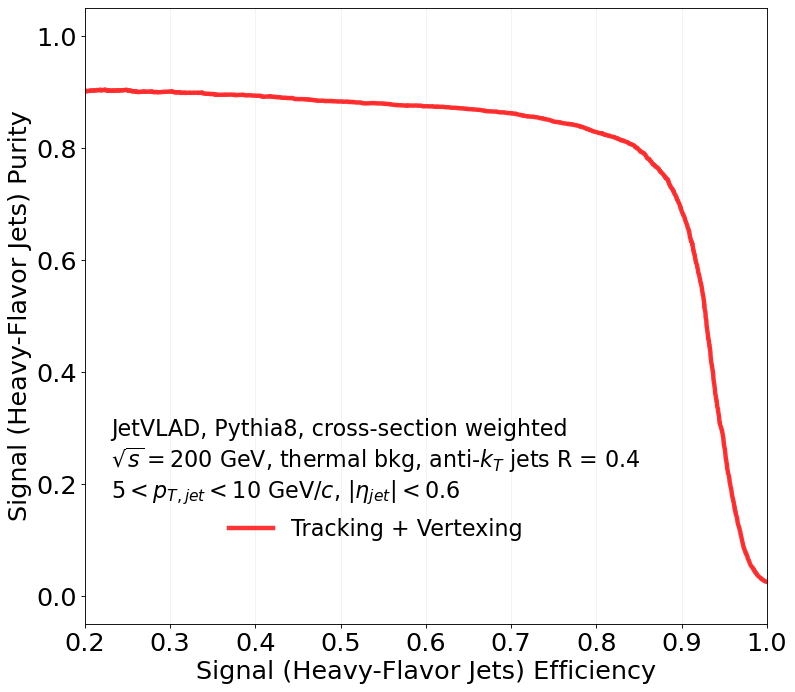

In [11]:
# Signal purity vs signal efficiency (make_plots.py layout).
plt.figure(figsize=(11, 10), dpi=80, facecolor='w', edgecolor='k')
plt.plot(mean_rec, prec_trkvtx, color='red', label=r'Tracking + Vertexing',
         lw=4, alpha=.8, linestyle='-')
plt.fill_between(mean_rec, precs_lower, precs_upper, color='red', alpha=.2)
plt.xlim([0.2, 1])
plt.ylim([-0.05, 1.05])
plt.grid(axis='x', color='0.95')
plt.xticks(np.arange(0.2, 1.1, 0.1), fontsize=23)
plt.yticks(fontsize=23)
plt.xlabel('Signal (Heavy-Flavor Jets) Efficiency', fontsize=23)
plt.ylabel('Signal (Heavy-Flavor Jets) Purity', fontsize=23)
plt.legend(loc=(0.025, 0.12), fancybox=True, framealpha=0., fontsize=20,
           title=label_title, title_fontsize=20)
plt.savefig('netvlad_purity.pdf', bbox_inches='tight')
plt.show()


In [12]:
# Working points, same printout as make_plots.py.
idx_eff_80 = np.abs(0.80 - tpr_trkvtx).argmin()
idx_pur_80 = np.abs(0.80 - mean_rec).argmin()
idx_eff_50 = np.abs(0.50 - tpr_trkvtx).argmin()
idx_pur_50 = np.abs(0.50 - mean_rec).argmin()
print('Rejection@80eff: ', 1/mean_fpr[idx_eff_80])
print('Prec@80eff: ', prec_trkvtx[idx_pur_80])
print('Rejection@50eff: ', 1/mean_fpr[idx_eff_50])
print('Prec@50eff: ', prec_trkvtx[idx_pur_50])


Rejection@80eff:  236.68061284271198
Prec@80eff:  0.8280555443162955
Rejection@50eff:  579.696490948357
Prec@50eff:  0.8825344872130164
